# **Evaluation of the model**

In [2]:
import pandas as pd

raw = pd.read_csv('../data/all_ufc_data_raw.csv')
processed = pd.read_csv('../data/all_ufc_data_processed.csv')
fights = pd.read_csv('../data/df_fights.csv')

def eliminate_rows_post_23_08(df):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    return df[df['Date'] <= '2025-08-23']

raw.dropna(subset=['Date'], inplace=True)
processed.dropna(subset=['Date'], inplace=True)
fights.dropna(subset=['Date'], inplace=True)

raw.to_csv('../data/all_ufc_data_raw.csv', index=False)
processed.to_csv('../data/all_ufc_data_processed.csv', index=False)
fights.to_csv('../data/df_fights.csv', index=False)


C:\R\temp\ipykernel_1292\1927753460.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv('../data/all_ufc_data_raw.csv')


In [8]:
import pandas as pd

d = pd.read_csv('../data/all_ufc_data_raw.csv')

d['Date'] = pd.to_datetime(d['Date'], errors='coerce')

print(d['Date'].max())
print(d['Date'].min())

d

NaT
NaT


C:\R\temp\ipykernel_14776\720280880.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d['Date'] = pd.to_datetime(d['Date'], errors='coerce')


,Name,Opponent,Win,Weight_Class,Title_Bout,Method,Round,Time,Time_format,Referee,...,Fighter_B_Totals_Ctrl,Fighter_B_Significant_Strikes_Fighter,Fighter_B_Significant_Strikes_Sig_str,Fighter_B_Significant_Strikes_Sig_str_Pct,Fighter_B_Significant_Strikes_Head,Fighter_B_Significant_Strikes_Body,Fighter_B_Significant_Strikes_Leg,Fighter_B_Significant_Strikes_Distance,Fighter_B_Significant_Strikes_Clinch,Fighter_B_Significant_Strikes_Ground
0,Johnny Walker,Zhang Mingyang,1,Light Heavyweight,0,KO/TKO,2,2:37,5_Rnd_(5-5-5-5-5),Marc_Goddard,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Zhang Mingyang,Johnny Walker,0,Light Heavyweight,0,KO/TKO,2,2:37,5_Rnd_(5-5-5-5-5),Marc_Goddard,...,1:21,Zhang Mingyang,12 of 30,40%,6 of 24,5 of 5,1 of 1,7 of 22,4 of 6,1 of 2
2,Brian Ortega,Aljamain Sterling,0,Catch Weight,0,Decision - Unanimous,5,5:00,5_Rnd_(5-5-5-5-5),Herb_Dean,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aljamain Sterling,Brian Ortega,1,Catch Weight,0,Decision - Unanimous,5,5:00,5_Rnd_(5-5-5-5-5),Herb_Dean,...,0:00,Aljamain Sterling,27 of 44,61%,16 of 32,3 of 4,8 of 8,27 of 44,0 of 0,0 of 0
4,Sergei Pavlovich,Waldo Cortes-Acosta,1,Heavyweight,0,Decision - Unanimous,3,5:00,3_Rnd_(5-5-5),Marc_Goddard,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16643,David Levicki,Johnny Rhodes,0,Open Weight,0,KO/TKO,1,12:13,No_Time_Limit,John_McCarthy,...,--,David Levicki,4 of 5,80%,4 of 5,0 of 0,0 of 0,1 of 2,2 of 2,1 of 1
16644,Patrick Smith,Ray Wizard,1,Open Weight,0,Submission,1,0:58,No_Time_Limit,John_McCarthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16645,Ray Wizard,Patrick Smith,0,Open Weight,0,Submission,1,0:58,No_Time_Limit,John_McCarthy,...,--,Ray Wizard,1 of 1,100%,0 of 0,0 of 0,1 of 1,1 of 1,0 of 0,0 of 0
16646,Scott Morris,Sean Daugherty,1,Open Weight,0,Submission,1,0:20,No_Time_Limit,John_McCarthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Merge 2024 odds**

In [1]:
import pandas as pd, xgboost as xgb
from sklearn.model_selection import GridSearchCV

df_master = pd.read_csv("../ufc_prediction_project_1/data/ufc-master.csv").copy()

df_master.sort_values(by="Date", ascending=False).head()

info = df_master[df_master["Date"].str.contains("2024") | df_master["Date"].str.contains("2023")][['RedFighter', 'BlueFighter', 'RedExpectedValue', 'BlueExpectedValue', 'Date']]

info['Red_Odds'] = (info['RedExpectedValue'] / 100) + 1
info['Blue_Odds'] = (info['BlueExpectedValue'] / 100) + 1

del info['RedExpectedValue']
del info['BlueExpectedValue']

info.rename(columns = {'RedFighter': 'Fighter_A_Name', 'BlueFighter': 'Fighter_B_Name', 'Red_Odds': 'Odds_A', 'Blue_Odds': 'Odds_B'}, inplace = True)
info.head()


,Fighter_A_Name,Fighter_B_Name,Date,Odds_A,Odds_B
0,Alexandre Pantoja,Kai Asakura,2024-12-07,1.400000,3.15
1,Shavkat Rakhmonov,Ian Machado Garry,2024-12-07,1.476190,3.95
2,Ciryl Gane,Alexander Volkov,2024-12-07,1.263158,4.00
3,Bryce Mitchell,Kron Gracie,2024-12-07,1.105263,7.25
4,Nate Landwehr,Dooho Choi,2024-12-07,1.769231,2.10


In [2]:
df = pd.read_csv("data/df_fights.csv").copy()

testing_set = df[df["Date"].str.contains("2024") | df["Date"].str.contains("2023")]
training_set = df[~df["Date"].str.contains("2024") & ~df["Date"].str.contains("2023") | ~df["Date"].str.contains("2025")]

print(training_set.shape)
print(testing_set.shape)


(8341, 77)
(1037, 77)


In [3]:
def make_match_key(row):
    fighters = sorted([row['Fighter_A_Name'].strip().lower(), row['Fighter_B_Name'].strip().lower()])
    return f"{fighters[0]}_vs_{fighters[1]}_{str(row['Date']).strip().replace('-', '')}"

# Crear la clave en ambos df
testing_set['match_key'] = testing_set.apply(make_match_key, axis=1)
info['match_key'] = info.apply(make_match_key, axis=1)

merged = testing_set.merge(
    info[['match_key', 'Fighter_A_Name', 'Fighter_B_Name', 'Odds_A', 'Odds_B']],
    on='match_key',
    how ='left',
    suffixes=('', '_info')
)

merged.dropna(subset=['Odds_A', 'Odds_B'], inplace=True)

print(merged.shape)

None

(785, 82)


C:\Users\juanl\AppData\Local\Temp\ipykernel_11780\3308147707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing_set['match_key'] = testing_set.apply(make_match_key, axis=1)


## **Create model**

In [4]:
y_train = training_set.pop("Winner_A")
y_test = testing_set.pop("Winner_A")

X_train = training_set.drop(columns=['Fighter_A_Name', 'Fighter_B_Name', 'Date', 'Referee', 'Location', 'Country',
						'N_Rounds', 'Max_Time', 'Method', 'Round', 'Time', 'Time_format'])
X_test = testing_set.drop(columns=['Fighter_A_Name', 'Fighter_B_Name', 'Date', 'Referee', 'Location', 'Country',
						'N_Rounds', 'Max_Time', 'Method', 'Round', 'Time', 'Time_format'])
X_train = pd.get_dummies(X_train, columns=['Weight_Class', 'Continent', 'Season'])
X_test = pd.get_dummies(X_test, columns=['Weight_Class', 'Continent', 'Season'])

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Create the base model and use GridSearch to find the best hyperparameters
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

param_grid = {
    'n_estimators': [200],
    'learning_rate': [0.04, 0.06, 0.08],
    'colsample_bytree': [0.8],
    'max_depth': [2, 3, 4],
    'subsample': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
    }

grid = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='accuracy', cv=5)

# Train the model
grid.fit(X_train, y_train)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Remove any columns that should not be in the features (if present)
X_test = X_test.loc[:, X_train.columns]

# Remove any columns that should not be in the features (if present)
X_test_features = X_test.drop(columns=[col for col in ['Predicted_Winner_A', 'Predicted_Prob_Winner_A'] if col in X_test.columns])

# Predictions
y_pred = grid.predict(X_test_features)
y_pred_proba = grid.predict_proba(X_test_features)[:, 1]

X_test['Predicted_Winner_A'] = y_pred
X_test['Predicted_Prob_Winner_A'] = y_pred_proba

print("Best Hyperparameters:", grid.best_params_)

print("Training Accuracy:", grid.score(X_train, y_train))

print("Testing Accuracy:", grid.score(X_test_features, y_test), '\n')

print("Mean Predicted Probability (Winner A):", y_pred_proba.mean(), '\n')

Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.06, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
Training Accuracy: 0.6302601606522
Testing Accuracy: 0.6325940212150434 

Mean Predicted Probability (Winner A): 0.49148816 



## **Creating bet df**

In [ ]:
# Ensure we have a key to align predictions with merged DataFrame
testing_set = testing_set.copy()
testing_set['match_key'] = testing_set.apply(make_match_key, axis=1)

# Create DataFrame for predictions
pred_df = pd.DataFrame({
    'match_key': testing_set['match_key'].values,
    'Fighter_A_Name': testing_set['Fighter_A_Name'].values,
    'Fighter_B_Name': testing_set['Fighter_B_Name'].values,
    'Date': testing_set['Date'].values,
    'Winner_A': y_test.values,
    'Predicted_Winner_A': y_pred,
    'Predicted_Prob_Winner_A': y_pred_proba,
    'Predicted_Prob_Winner_B': 1 - y_pred_proba
})

# Merge with odds from merged DataFrame
prediction_df = pd.merge(
    pred_df,
    merged[['match_key', 'Odds_A', 'Odds_B']],
    on='match_key',
    how='left'
)

prediction_df['Expected_Value_A'] = prediction_df['Predicted_Prob_Winner_A'] * prediction_df['Odds_A'] - 1
prediction_df['Expected_Value_B'] = prediction_df['Predicted_Prob_Winner_B'] * prediction_df['Odds_B'] - 1

In [ ]:
prediction_df.to_csv("data/model_evaluation_results.csv", index=False)

print(f'Shape of the dataframe: {prediction_df.shape}\n')
prediction_df.head()

## **Making betting suggestions: Bet if EV > 0 + th and p > m**

In [1]:
import pandas as pd

prediction_df = pd.read_csv("data/model_evaluation_results.csv").copy()

In [2]:
mean_odds_a = prediction_df['Odds_A'].mean()
mean_odds_b = prediction_df['Odds_B'].mean()

print(f'Mean Odds A: {mean_odds_a}, Mean Odds B: {mean_odds_b}')

print(f'Range Odds A: {prediction_df["Odds_A"].min()} - {prediction_df["Odds_A"].max()}')
print(f'Range Odds B: {prediction_df["Odds_B"].min()} - {prediction_df["Odds_B"].max()}')

print(f'Implied Probability A: {1/mean_odds_a}, Implied Probability B: {1/mean_odds_b}')

print(f'Average total probability: {1 / mean_odds_a + 1 / mean_odds_b}')

m, n = 0, 0
for _, row in prediction_df[prediction_df['Odds_A'].notnull() & prediction_df['Odds_B'].notnull()].iterrows():
    m += (1 / row['Odds_A']) + (1 / row['Odds_B'])
    n += 1

print(f'Average total probability (iterative): {m/n}')

Mean Odds A: 2.0499148318471336, Mean Odds B: 2.6244438942675163
Range Odds A: 1.047619 - 8.0
Range Odds B: 1.090909 - 12.0
Implied Probability A: 0.48782514495927704, Implied Probability B: 0.3810331027400761
Average total probability: 0.8688582476993532
Average total probability (iterative): 1.0426587025849103


In [3]:
# print(prediction_df[['Odds_A', 'Odds_B']].describe())
# print(prediction_df[['Odds_A', 'Odds_B']].sort_values(by='Odds_A', ascending=False).head(10))


In [4]:
import numpy as np, matplotlib.pyplot as plt
from math import sqrt

def select_bet(row, th = 1.25, m = 0.5):
    ev_a, ev_b = row['Expected_Value_A'], row['Expected_Value_B']
    p_a, p_b = row['Predicted_Prob_Winner_A'], row['Predicted_Prob_Winner_B']
    
    def bet_risk(ev):
        if ev <= th:
            return 'No Bet'
        elif ev >= th * 1.6:
            return 'Low'
        elif ev >= th * 1.3:
            return 'Medium'
        else:
            return 'High'
    
    if ev_a <= 0 and ev_b <= 0:
        return 'No Bet', 0, 'No Bet', 'No Bet'
    if ev_a >= ev_b and ev_a > th and p_a > m:
        return row['Fighter_A_Name'], ev_a, 1, bet_risk(ev_a)
    elif ev_b > ev_a and ev_b > th and p_b > m:
        return row['Fighter_B_Name'], ev_b, 0, bet_risk(ev_b)
    else:
        return 'No Bet', 0, 'No Bet', 'No Bet'

l = list()

for threshold in np.arange(1, 1.51, 0.02):
    for m in np.arange(0.4, 0.55, 0.02):
        bet_info = prediction_df.apply(select_bet, axis=1, result_type='expand', th = threshold, m = m)
        prediction_df['Bet'] = bet_info[0]
        prediction_df['Bet_EV'] = bet_info[1]
        prediction_df['Bet_Fighter_A'] = bet_info[2]
        prediction_df['Bet_Risk'] = bet_info[3]

        # Calculate accuracy
        accuracy = len(prediction_df[prediction_df['Winner_A'] == prediction_df['Bet_Fighter_A']]) / len(prediction_df[prediction_df['Bet_Fighter_A'] != 'No Bet'])
        
        # Calculate profit
        profit = 0
        for _, row in prediction_df.iterrows():
            if row['Bet_Fighter_A'] != 'No Bet':
                if row['Bet_Fighter_A'] == row['Winner_A']:
                    if row['Bet_Fighter_A'] == 1:
                        profit += row['Odds_A'] - 1
                    elif row['Bet_Fighter_A'] == 0:
                        profit += row['Odds_B'] - 1
                else:
                    profit -= 1
        
        n_bets = prediction_df[prediction_df['Bet_Fighter_A'] != 'No Bet'].shape[0]
        
        roi = (profit / n_bets * 100) if n_bets > 0 else 0
        
        d = {
            'Threshold': round(threshold, 2),
            'M': round(m, 2),
            'Bets': n_bets,
            'Accuracy': round(accuracy, 2),
            'Profit': round(profit, 2),
            'ROI': round(roi, 2)
        }
        
        l.append(d)

results_df = pd.DataFrame(l)

results_df['Accuracy_100'] = results_df['Accuracy'] * 100

def score(row):
    return (row['ROI'] * sqrt(row['Bets'])) / 10

results_df['Score'] = results_df.apply(score, axis=1)

# Visualization with a multiple line plot (one line for each variable between Bets and ROI)
"""plt.figure(figsize=(10, 8))
plt.plot(results_df['Bets'], marker='o', label='Number of Bets')
plt.plot(results_df['ROI'], marker='o', label='ROI (%)')
plt.plot(results_df['Accuracy_100'], marker='o', label='Accuracy (%)')
plt.plot(results_df['Profit'], marker='o', label='Nominal Profit (€)')
plt.plot(results_df['Score'], marker='o', label='Yield Score')
plt.plot()
plt.title('Betting Strategy Evaluation Metrics', fontsize=16)
plt.xlabel('Threshold', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.legend()
None"""

"plt.figure(figsize=(10, 8))\nplt.plot(results_df['Bets'], marker='o', label='Number of Bets')\nplt.plot(results_df['ROI'], marker='o', label='ROI (%)')\nplt.plot(results_df['Accuracy_100'], marker='o', label='Accuracy (%)')\nplt.plot(results_df['Profit'], marker='o', label='Nominal Profit (€)')\nplt.plot(results_df['Score'], marker='o', label='Yield Score')\nplt.plot()\nplt.title('Betting Strategy Evaluation Metrics', fontsize=16)\nplt.xlabel('Threshold', fontsize=14)\nplt.ylabel('Value', fontsize=14)\nplt.legend()\nNone"

In [5]:
# prediction_df[prediction_df['Bet'] != 'No Bet'].head()

In [6]:
results_df.head()

,Threshold,M,Bets,Accuracy,Profit,ROI,Accuracy_100,Score
0,1.0,0.40,124,0.70,320.65,258.59,70.0,287.953637
1,1.0,0.42,120,0.72,324.65,270.54,72.0,296.361721
2,1.0,0.44,114,0.75,319.15,279.96,75.0,298.915483
3,1.0,0.46,109,0.76,310.15,284.54,76.0,297.068481
4,1.0,0.48,105,0.78,309.55,294.81,78.0,302.090356


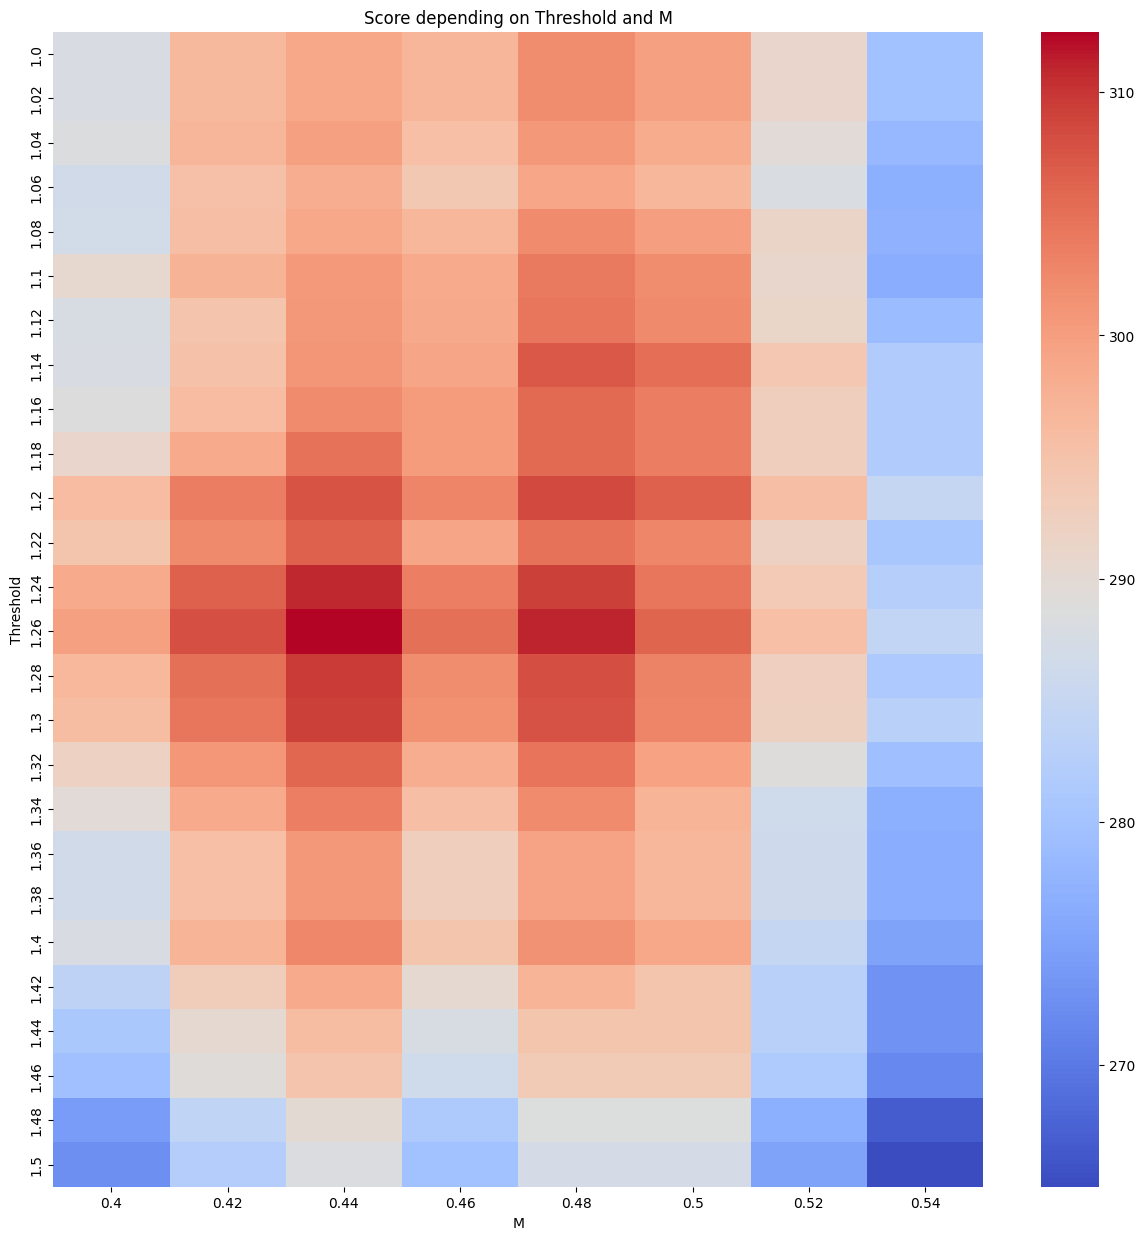

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# df_metrics: columnas ['threshold', 'm', 'n_bets', 'roi', ...]
pivot_table = results_df.pivot(index="Threshold", columns="M", values="Score")  # Cambia "roi" por la métrica que quieras
plt.figure(figsize = (15, 15))
sns.heatmap(pivot_table, annot=False, fmt=".2f", cmap="coolwarm")
plt.title("Score depending on Threshold and M")
plt.show()


In [8]:
# Show the whole dataframe
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# display(results_df)

# Let's see the best threshold according to the Score
best_row = results_df.loc[results_df['Score'].idxmax()]
best_th, best_m = best_row['Threshold'], best_row['M']
print("\nBest Threshold based on Score:", best_th)
print("Best M based on Score:", best_m)
print('Best situation:', best_row.to_dict())


Best Threshold based on Score: 1.26
Best M based on Score: 0.44
Best situation: {'Threshold': 1.26, 'M': 0.44, 'Bets': 84.0, 'Accuracy': 0.81, 'Profit': 286.4, 'ROI': 340.95, 'Accuracy_100': 81.0, 'Score': 312.48583663903867}


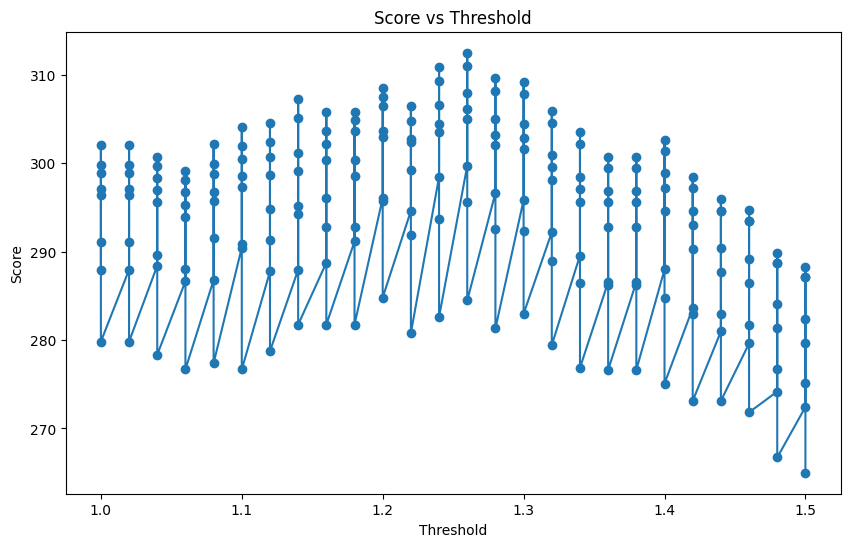

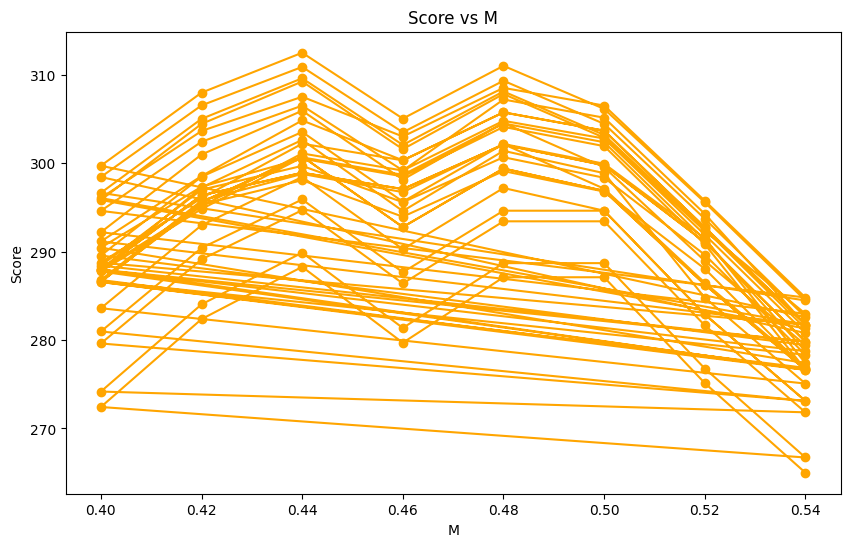

In [9]:
import matplotlib.pyplot as plt

# Plot the Score vs Threshold
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Score'], marker='o')
plt.title('Score vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results_df['M'], results_df['Score'], marker='o', color='orange')
plt.title('Score vs M')
plt.xlabel('M')
plt.ylabel('Score')
plt.show()

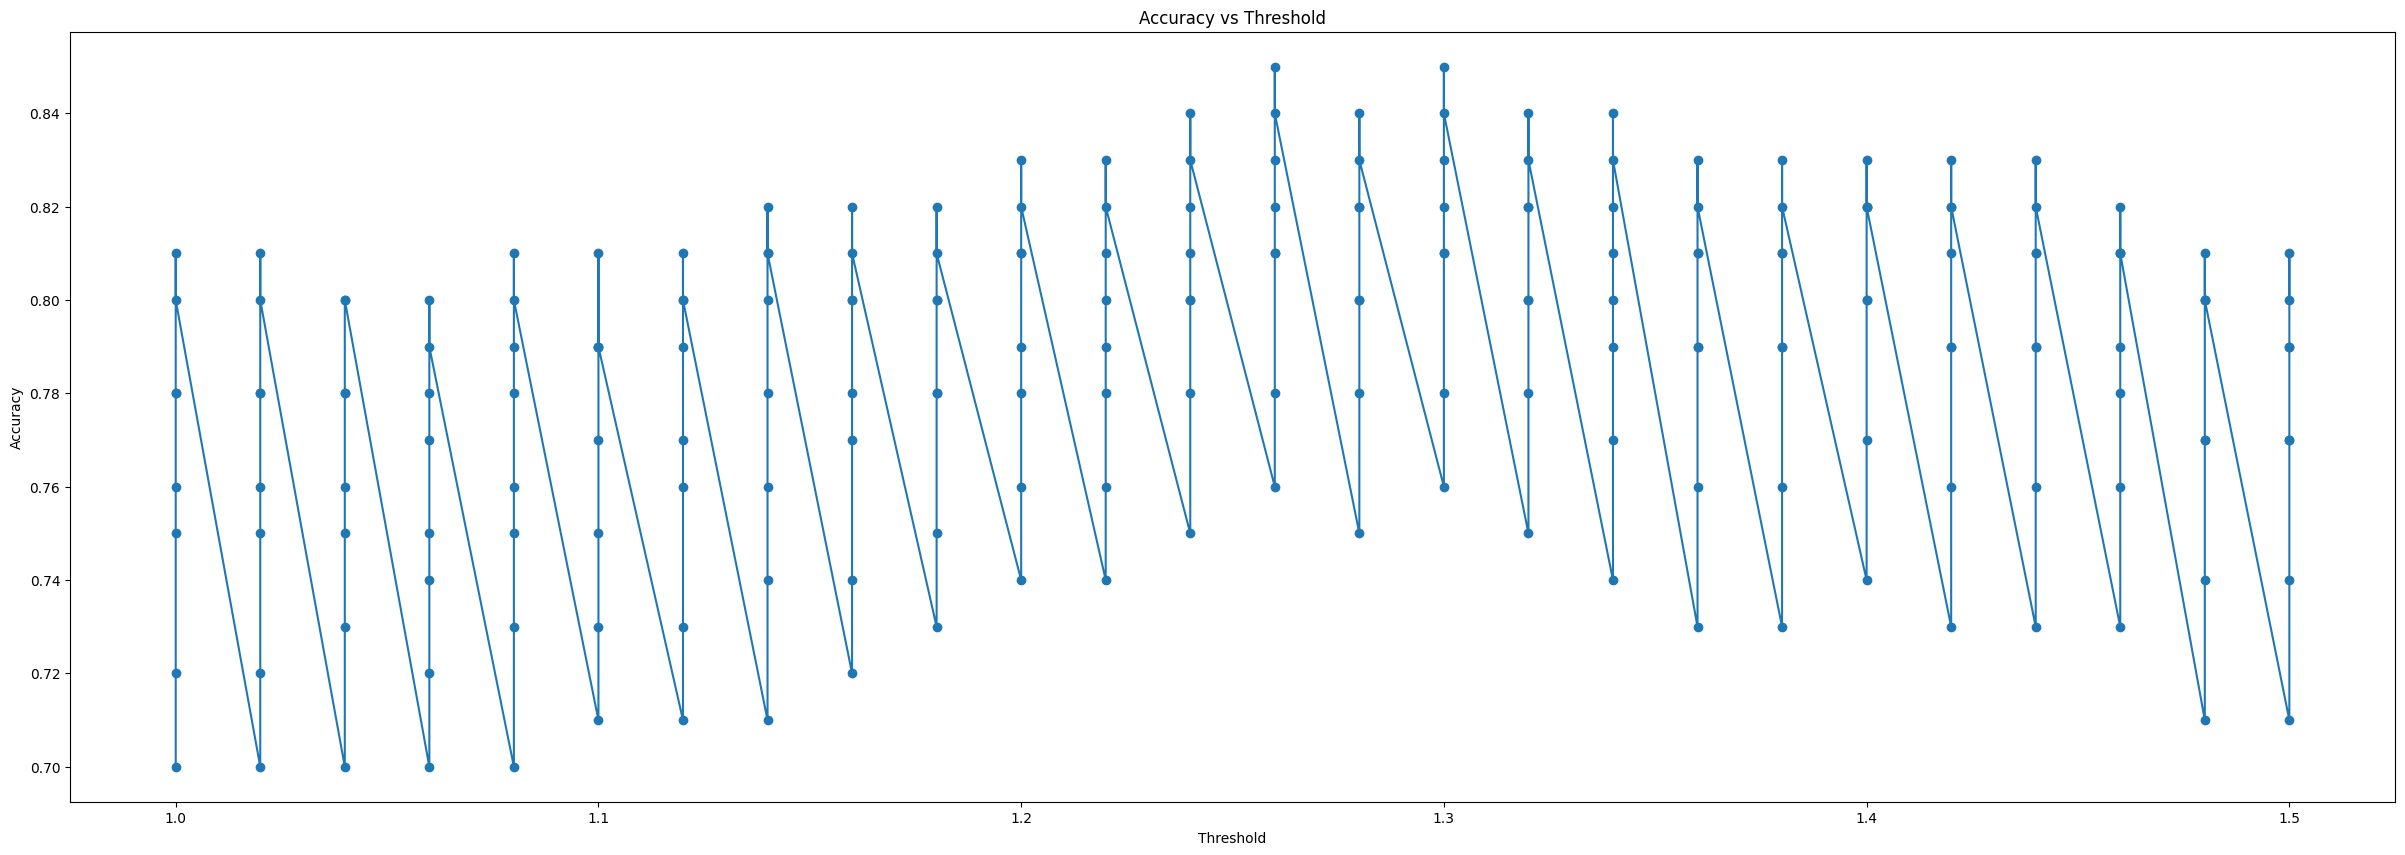

In [10]:
import matplotlib.pyplot as plt

# Plot the Score vs Threshold
plt.figure(figsize=(30, 10))
plt.plot(results_df['Threshold'], results_df['Accuracy'], marker='o')
plt.title('Accuracy vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.show()

### **Simulation**

Having bet on 80 fights and guessed 66 correctly
We would have had 82.5% accuracy
Net profit (excluding savings): 5620.75€
Total saved (withdrawn): 1470.19€
Final bankroll: 4250.56€
Total value (bankroll + savings): 5720.75€
Total staked: 1370.0€
ROI: 410.27%


C:\Users\juanl\AppData\Local\Temp\ipykernel_11412\3609176741.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[15.0, 5.0, 30.0, 5.0, 30.0, 5.0, 30.0, 5.0, 5.0, 30.0, 30.0, 5.0, 15.0, 30.0, 5.0, 30.0, 30.0, 5.0, 30.0, 30.0, 15.0, 5.0, 15.0, 30.0, 15.0, 5.0, 15.0, 15.0, 5.0, 30.0, 5.0, 30.0, 30.0, 5.0, 15.0, 5.0, 30.0, 30.0, 15.0, 30.0, 15.0, 15.0, 5.0, 30.0, 5.0, 15.0, 30.0, 30.0, 5.0, 5.0, 5.0, 5.0, 5.0, 30.0, 15.0, 30.0, 5.0, 15.0, 30.0, 5.0, 30.0, 30.0, 5.0, 5.0, 5.0, 5.0, 15.0, 30.0, 5.0, 5.0, 30.0, 30.0, 5.0, 30.0, 30.0, 15.0, 30.0, 5.0, 15.0, 30.0]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  prediction_df.loc[prediction_df['Bet_Fighter_A'] != 'No Bet', 'Stake_Amount'] = stake_history


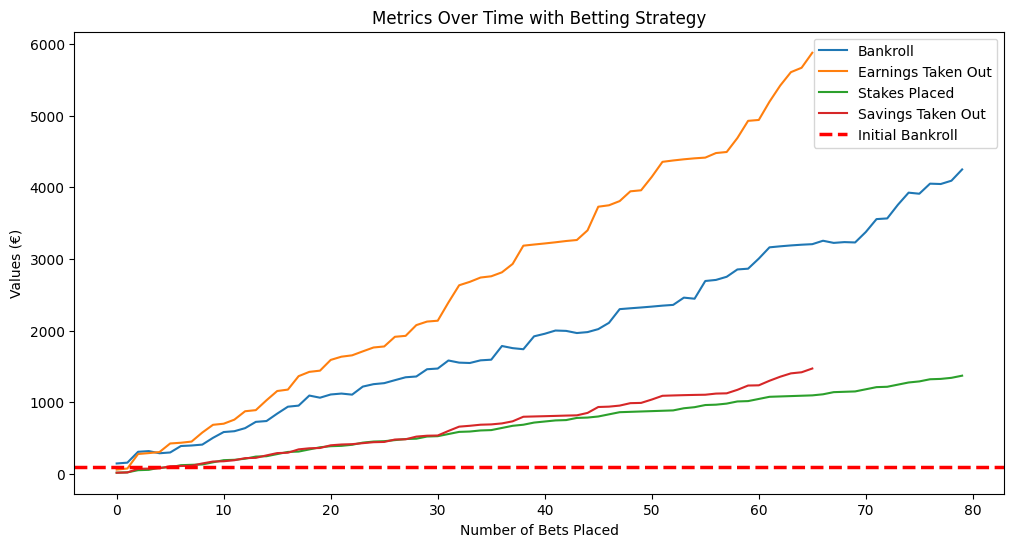

In [11]:
bet_info = prediction_df.apply(select_bet, axis=1, result_type='expand')
prediction_df['Bet'], prediction_df['Bet_EV'], prediction_df['Bet_Fighter_A'], prediction_df['Bet_Risk'] = bet_info[0], bet_info[1], bet_info[2], bet_info[3]

n_bets, n_bets_right = 0, 0
total_earnings, earning_history = 0, []
total_saved, saving_history = 0, []
total_staked, stake_history = 0, []
initial_bankroll, current_bankroll, bankroll_history = 100, 100, []

def select_bet_amount(row, initial_bankroll):
        if row['Bet_Risk'] == 'Low':
            return initial_bankroll * 0.3
        elif row['Bet_Risk'] == 'Medium':
            return initial_bankroll * 0.15
        elif row['Bet_Risk'] == 'High':
            return initial_bankroll * 0.05
        return 0

for _, row in prediction_df[prediction_df['Bet_Fighter_A'] != 'No Bet'].iterrows():
        bet_amount = select_bet_amount(row, initial_bankroll)
        
        if current_bankroll >= bet_amount and bet_amount > 0:
            
            total_staked += bet_amount
            stake_history.append(bet_amount)
            
            current_bankroll -= bet_amount
            
            if row['Bet_Fighter_A'] == row['Winner_A']:
                if row['Bet_Fighter_A'] == 1:
                    gross_win = row['Odds_A'] * bet_amount
                else:
                    gross_win = row['Odds_B'] * bet_amount
                
                profit = gross_win - bet_amount
                
                current_bankroll += gross_win
                
                saving = profit * 0.25
                total_saved += saving
                saving_history.append(saving)
                current_bankroll -= saving
                
                total_earnings += profit
                earning_history.append(profit)
                
                n_bets_right += 1
                
            else:
                total_earnings -= bet_amount
                
            bankroll_history.append(current_bankroll)
            n_bets += 1
        
        else:
            stake_history.append(0)
            earning_history.append(0)
            saving_history.append(0)
            

# Create a new column in prediction_df to store the stake amounts
prediction_df['Stake_Amount'] = 0
prediction_df.loc[prediction_df['Bet_Fighter_A'] != 'No Bet', 'Stake_Amount'] = stake_history

print(f"Having bet on {n_bets} fights and guessed {n_bets_right} correctly")
print(f"We would have had {round((n_bets_right / n_bets) * 100, 2)}% accuracy")
print(f"Net profit (excluding savings): {round(total_earnings, 2)}€")
print(f"Total saved (withdrawn): {round(total_saved, 2)}€")
print(f"Final bankroll: {round(current_bankroll, 2)}€")
print(f"Total value (bankroll + savings): {round(current_bankroll + total_saved, 2)}€")
print(f"Total staked: {round(total_staked, 2)}€")
print(f"ROI: {round((total_earnings / total_staked) * 100, 2)}%")

plt.figure(figsize=(12, 6))
plt.plot(bankroll_history, label='Bankroll')
plt.plot(np.cumsum(earning_history), label='Earnings Taken Out')
plt.plot(np.cumsum(stake_history), label='Stakes Placed')
plt.plot(np.cumsum(saving_history), label='Savings Taken Out')
plt.title('Metrics Over Time with Betting Strategy')
plt.xlabel('Number of Bets Placed')
plt.ylabel('Values (€)')
plt.axhline(y=initial_bankroll, color='r', linestyle='--', linewidth=2.5, label='Initial Bankroll')
plt.legend()
plt.show()
None

In [12]:
prediction_df[prediction_df['Bet'] != 'No Bet'].head()

,match_key,Fighter_A_Name,Fighter_B_Name,Date,Winner_A,Predicted_Winner_A,Predicted_Prob_Winner_A,Predicted_Prob_Winner_B,Odds_A,Odds_B,Expected_Value_A,Expected_Value_B,Bet,Bet_EV,Bet_Fighter_A,Bet_Risk,Stake_Amount
16,gilbert burns_vs_neil magny_20230121,Neil Magny,Gilbert Burns,2023-01-21,0,0,0.422128,0.577872,1.204082,4.900000,-0.491723,1.831571,Gilbert Burns,1.831571,0,Medium,15.0
23,cody stamann_vs_luan lacerda_20230121,Cody Stamann,Luan Lacerda,2023-01-21,1,1,0.596674,0.403326,4.000000,1.273973,1.386695,-0.486173,Cody Stamann,1.386695,1,High,5.0
24,jailton almeida_vs_shamil abdurakhimov_20230121,Jailton Almeida,Shamil Abdurakhimov,2023-01-21,1,1,0.760648,0.239352,7.750000,1.102564,4.895019,-0.736099,Jailton Almeida,4.895019,1,Low,30.0
30,derrick lewis_vs_serghei spivac_20230204,Serghei Spivac,Derrick Lewis,2023-02-04,1,1,0.651835,0.348165,3.550000,1.327869,1.314015,-0.537683,Serghei Spivac,1.314015,1,High,5.0
31,rinya nakamura_vs_toshiomi kazama_20230204,Toshiomi Kazama,Rinya Nakamura,2023-02-04,0,1,0.632135,0.367865,5.500000,1.166667,2.476740,-0.570824,Toshiomi Kazama,2.476740,1,Low,30.0


In [13]:
print(bankroll_history)

# Let's see the best and worst bet streaks
best_streak, worst_streak, current_streak = 0, 0, 0
n_bets_right, n_bets_wrong = 0, 0

for _, row in prediction_df.iterrows():
	if row['Bet_Fighter_A'] != 'No Bet':
		if row['Bet_Fighter_A'] == row['Winner_A']:
			current_streak += 1
			n_bets_right += 1
			best_streak = max(best_streak, current_streak)
		else:
			current_streak -= 1
			n_bets_wrong += 1
			worst_streak = min(worst_streak, current_streak)

print(f"Best Winning Streak: {best_streak}, Worst Losing Streak: {abs(worst_streak)}")
print(f"Total Bets Right: {n_bets_right}, Total Bets Wrong: {n_bets_wrong}")

[143.875, 155.125, 307.0, 316.5625, 286.5625, 297.4375, 387.4375, 394.9375, 407.3125, 501.8125, 582.8125, 594.4375, 637.1875, 724.9375, 736.5625, 840.0625, 936.8125, 951.8125, 1092.4375, 1062.4375, 1107.4375, 1120.1875, 1105.1875, 1217.6875, 1251.4375, 1265.6875, 1307.3125, 1347.8125, 1358.6875, 1459.9375, 1469.6875, 1582.1875, 1552.1875, 1547.1875, 1584.3125, 1593.3125, 1784.5625, 1754.5625, 1739.5625, 1919.5625, 1955.5625, 2000.5625, 1995.5625, 1965.5625, 1978.6875, 2020.3125, 2108.0625, 2299.3125, 2311.3125, 2322.5625, 2334.75, 2348.25, 2358.75, 2460.0, 2445.0, 2692.5, 2707.5, 2751.375, 2853.75, 2864.4375, 3005.0625, 3162.5625, 3176.8125, 3189.1875, 3199.3125, 3206.8125, 3254.625, 3224.625, 3235.6875, 3230.6875, 3376.9375, 3556.9375, 3566.3125, 3757.5625, 3926.3125, 3911.3125, 4051.9375, 4046.9375, 4093.0625, 4250.5625]
Best Winning Streak: 52, Worst Losing Streak: 0
Total Bets Right: 66, Total Bets Wrong: 14


By betting on bets with EV > 1.25, we get: {'Threshold': 1.25, 'Bets': 99.0, 'Accuracy': 0.72, 'Profit': 291.8, 'ROI': 294.75, 'Accuracy_100': 72.0, 'Score': 293.27254708717624}

In [14]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(prediction_df[(prediction_df['Bet'] != 'No Bet') & (prediction_df['Bet_Fighter_A'] != prediction_df['Winner_A'])])

,match_key,Fighter_A_Name,Fighter_B_Name,Date,Winner_A,Predicted_Winner_A,Predicted_Prob_Winner_A,Predicted_Prob_Winner_B,Odds_A,Odds_B,Expected_Value_A,Expected_Value_B,Bet,Bet_EV,Bet_Fighter_A,Bet_Risk,Stake_Amount
31,rinya nakamura_vs_toshiomi kazama_20230204,Toshiomi Kazama,Rinya Nakamura,2023-02-04,0,1,0.632135,0.367865,5.500000,1.166667,2.476740,-0.570824,Toshiomi Kazama,2.476740,1,Low,30.0
361,chan sung jung_vs_max holloway_20230826,Max Holloway,Chan Sung Jung,2023-08-26,1,0,0.494164,0.505836,1.142857,6.000000,-0.435242,2.035018,Chan Sung Jung,2.035018,0,Low,30.0
384,israel adesanya_vs_sean strickland_20230909,Sean Strickland,Israel Adesanya,2023-09-09,1,0,0.437811,0.562189,1.181818,5.100000,-0.482587,1.867163,Israel Adesanya,1.867163,0,Medium,15.0
528,jean silva_vs_westin wilson_20240113,Westin Wilson,Jean Silva,2024-01-13,0,1,0.571484,0.428516,7.250000,1.105263,3.143260,-0.526377,Westin Wilson,3.143260,1,Low,30.0
533,mike malott_vs_neil magny_20240120,Mike Malott,Neil Magny,2024-01-20,0,1,0.638553,0.361447,4.000000,1.263158,1.554213,-0.543436,Mike Malott,1.554213,1,High,5.0
586,sam hughes_vs_yazmin jauregui_20240224,Yazmin Jauregui,Sam Hughes,2024-02-24,1,0,0.448452,0.551547,1.125000,6.500000,-0.495491,2.585059,Sam Hughes,2.585059,0,Low,30.0
590,daniel lacerda_vs_edgar chairez_20240224,Edgar Chairez,Daniel Lacerda,2024-02-24,1,0,0.435215,0.564785,1.200000,4.800000,-0.477742,1.710968,Daniel Lacerda,1.710968,0,Medium,15.0
603,christian leroy duncan_vs_claudio ribeiro_2024...,Christian Leroy Duncan,Claudio Ribeiro,2024-03-02,1,0,0.455960,0.544040,1.243902,4.200000,-0.432830,1.284967,Claudio Ribeiro,1.284967,0,High,5.0
621,kennedy nzechukwu_vs_ovince saint preux_20240316,Kennedy Nzechukwu,Ovince Saint Preux,2024-03-16,0,1,0.549483,0.450517,5.550000,1.160000,2.049629,-0.477400,Kennedy Nzechukwu,2.049629,1,Low,30.0
856,dan hooker_vs_mateusz gamrot_20240817,Dan Hooker,Mateusz Gamrot,2024-08-17,1,0,0.343605,0.656395,1.224719,4.100000,-0.579180,1.691218,Mateusz Gamrot,1.691218,0,Medium,15.0


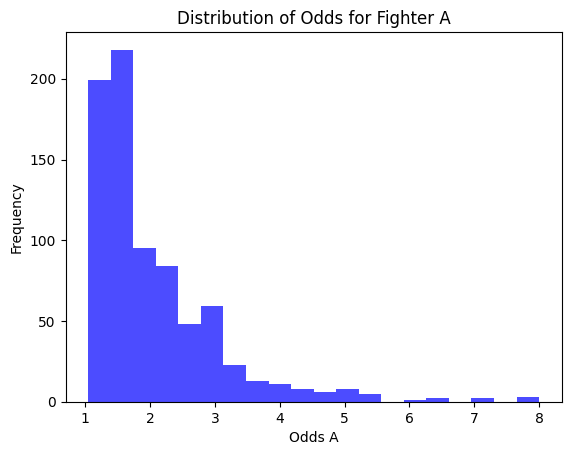

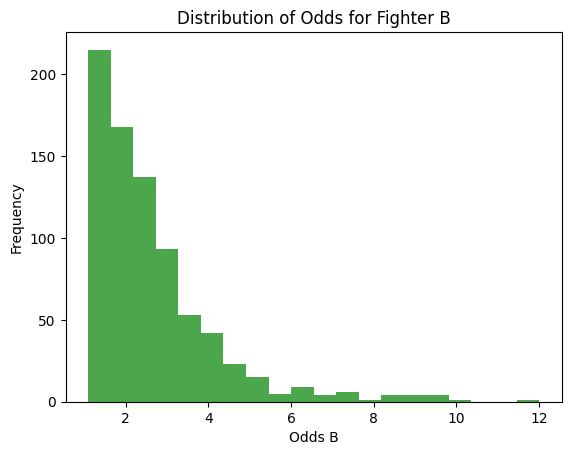

In [16]:
plt.hist(prediction_df['Odds_A'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Odds for Fighter A')
plt.xlabel('Odds A')
plt.ylabel('Frequency')
plt.show()

plt.hist(prediction_df['Odds_B'], bins=20, color='green', alpha=0.7)
plt.title('Distribution of Odds for Fighter B')
plt.xlabel('Odds B')
plt.ylabel('Frequency')
plt.show()

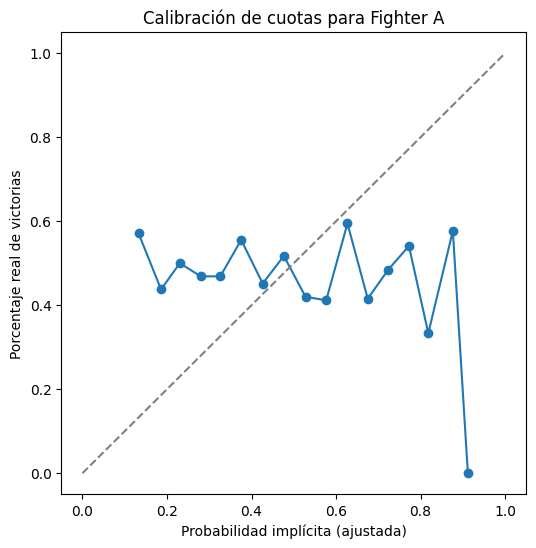

In [20]:
prediction_df['ImpliedProb_A'] = 1 / prediction_df['Odds_A']
prediction_df['ImpliedProb_B'] = 1 / prediction_df['Odds_B']

# Normaliza por el overround (margen de la casa)
prediction_df['Overround'] = prediction_df['ImpliedProb_A'] + prediction_df['ImpliedProb_B']
prediction_df['NormProb_A'] = prediction_df['ImpliedProb_A'] / prediction_df['Overround']
prediction_df['NormProb_B'] = prediction_df['ImpliedProb_B'] / prediction_df['Overround']

prediction_df.drop(columns=['ImpliedProb_A', 'ImpliedProb_B', 'Overround'], inplace=True)



# Agrupa por rangos de probabilidad implícita
prediction_df['Bin_A'] = pd.cut(prediction_df['NormProb_A'], bins=np.arange(0, 1.05, 0.05))
reliability = prediction_df.groupby('Bin_A', observed=False).agg(
    Real_Win_Rate_A=('Winner_A', 'mean'),
    Mean_Implied_Prob_A=('NormProb_A', 'mean'),
    n=('Winner_A', 'count')
).dropna()

# Plot de calibración
plt.figure(figsize=(6,6))
plt.plot(reliability['Mean_Implied_Prob_A'], reliability['Real_Win_Rate_A'], 'o-')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("Probabilidad implícita (ajustada)")
plt.ylabel("Porcentaje real de victorias")
plt.title("Calibración de cuotas para Fighter A")
plt.show()
None